In [ ]:
# Egypt Houses Price Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. Loading and displaying first 10 rows:


In [ ]:
df = pd.read_csv('Egypt_Houses_Prices.csv')
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,Type,Price,Bedrooms,Bathrooms,Area,Furnished,Level,Compound,Payment_Option,Delivery_Date,Delivery_Term,City
0,Duplex,4000000,3,3,400,No,7,Unknown,Cash,Ready to move,Finished,Nasr City
1,Apartment,4000000,3,3,160,No,10+,Unknown,Cash,Ready to move,Finished,Camp Caesar
2,Apartment,2250000,3,2,165,No,1,Unknown,Cash,Ready to move,Finished,Smoha
3,Apartment,1900000,3,2,230,No,10,Unknown,Cash,Ready to move,Finished,Nasr City
4,Apartment,5800000,2,3,160,No,Ground,Eastown,Cash,Ready to move,Semi Finished,New Cairo - El Tagamoa
5,Apartment,1844900,4,3,222,No,1,Beit Al Watan,Cash or Installment,2024,Semi Finished,New Cairo - El Tagamoa
6,Duplex,3900000,5,5,290,No,Highest,Jayd,Unknown Payment,Ready to move,Finished,New Cairo - El Tagamoa
7,Apartment,1650000,2,2,144,No,1,Zayed 2000,Unknown Payment,Ready to move,Finished,Sheikh Zayed
8,Apartment,1560000,3,3,200,Unknown,Ground,Unknown,Unknown Payment,Unknown,Semi Finished,New Cairo - El Tagamoa
9,Apartment,992800,3,2,146,Unknown,3,Unknown,Cash or Installment,2024,Semi Finished,New Cairo - El Tagamoa


2. Dataset summary and missing values:

In [107]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27361 entries, 0 to 27360
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Type            27361 non-null  object
 1   Price           27359 non-null  object
 2   Bedrooms        27158 non-null  object
 3   Bathrooms       27190 non-null  object
 4   Area            26890 non-null  object
 5   Furnished       27361 non-null  object
 6   Level           27361 non-null  object
 7   Compound        27361 non-null  object
 8   Payment_Option  27361 non-null  object
 9   Delivery_Date   27361 non-null  object
 10  Delivery_Term   27361 non-null  object
 11  City            27361 non-null  object
dtypes: object(12)
memory usage: 2.5+ MB


In [108]:
print("\nNumerical Column Statistics:")
df.describe()


Numerical Column Statistics:


,Type,Price,Bedrooms,Bathrooms,Area,Furnished,Level,Compound,Payment_Option,Delivery_Date,Delivery_Term,City
count,27361,27359,27158,27190,26890,27361,27361,27361,27361,27361,27361,27361
unique,11,4182,12,12,786,3,14,560,4,10,5,183
top,Apartment,3000000,3,2,120,No,Unknown,Unknown,Cash or Installment,Ready to move,Finished,New Cairo - El Tagamoa
freq,8506,311,11803,9186,663,16500,10439,11068,10842,12142,14375,6789


In [109]:
print("\nMissing Values Count:")
df.isnull().sum()


Missing Values Count:


Type                0
Price               2
Bedrooms          203
Bathrooms         171
Area              471
Furnished           0
Level               0
Compound            0
Payment_Option      0
Delivery_Date       0
Delivery_Term       0
City                0
dtype: int64

3. Handle missing values:

In [110]:
numerical_cols = ['Price', 'Bedrooms', 'Bathrooms', 'Area']
for col in numerical_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].mean())

categorical_cols = ['Type', 'Furnished', 'Level', 'Compound', 'Payment_Option', 'Delivery_Date', 'Delivery_Term', 'City']
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

4. Remove duplicates:

In [111]:
print("Shape before removing duplicates:", df.shape)
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape before removing duplicates: (27361, 12)
Shape after removing duplicates: (25434, 12)


5. One-hot encoding:

In [112]:
categorical_cols = ['Type', 'Furnished', 'Level', 'Compound', 'Payment_Option', 'Delivery_Date', 'Delivery_Term', 'City']
df_encoded = pd.get_dummies(df, columns=categorical_cols)

6. Normalize Price:

In [113]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['Price_Normalized'] = scaler.fit_transform(df[['Price']])

7. Group by Location:

In [114]:
avg_price_by_city = df.groupby('City')['Price'].mean().sort_values(ascending=False)
print("Average House Price by City:")
print(avg_price_by_city)

Average House Price by City:
City
Giza District          1.810125e+07
Mansuriyya             1.400000e+07
Gouna                  1.254258e+07
(View phone number)    9.971262e+06
Sadat                  9.950000e+06
                           ...     
Mit Ghamr              2.800000e+05
Minya al-Qamh          2.400000e+05
Dhahria                1.900000e+05
Dawahy District        1.527750e+05
Khosous                7.000000e+04
Name: Price, Length: 183, dtype: float64


8. Create Price per m²:

In [115]:
df['Price_per_m2'] = df['Price'] / df['Area']
print("\nFirst few rows with Price per m²:")
print(df[['Price', 'Area', 'Price_per_m2']].head())


First few rows with Price per m²:
       Price   Area  Price_per_m2
0  4000000.0  400.0  10000.000000
1  4000000.0  160.0  25000.000000
2  2250000.0  165.0  13636.363636
3  1900000.0  230.0   8260.869565
4  5800000.0  160.0  36250.000000


9. Visualize average Price per Location:

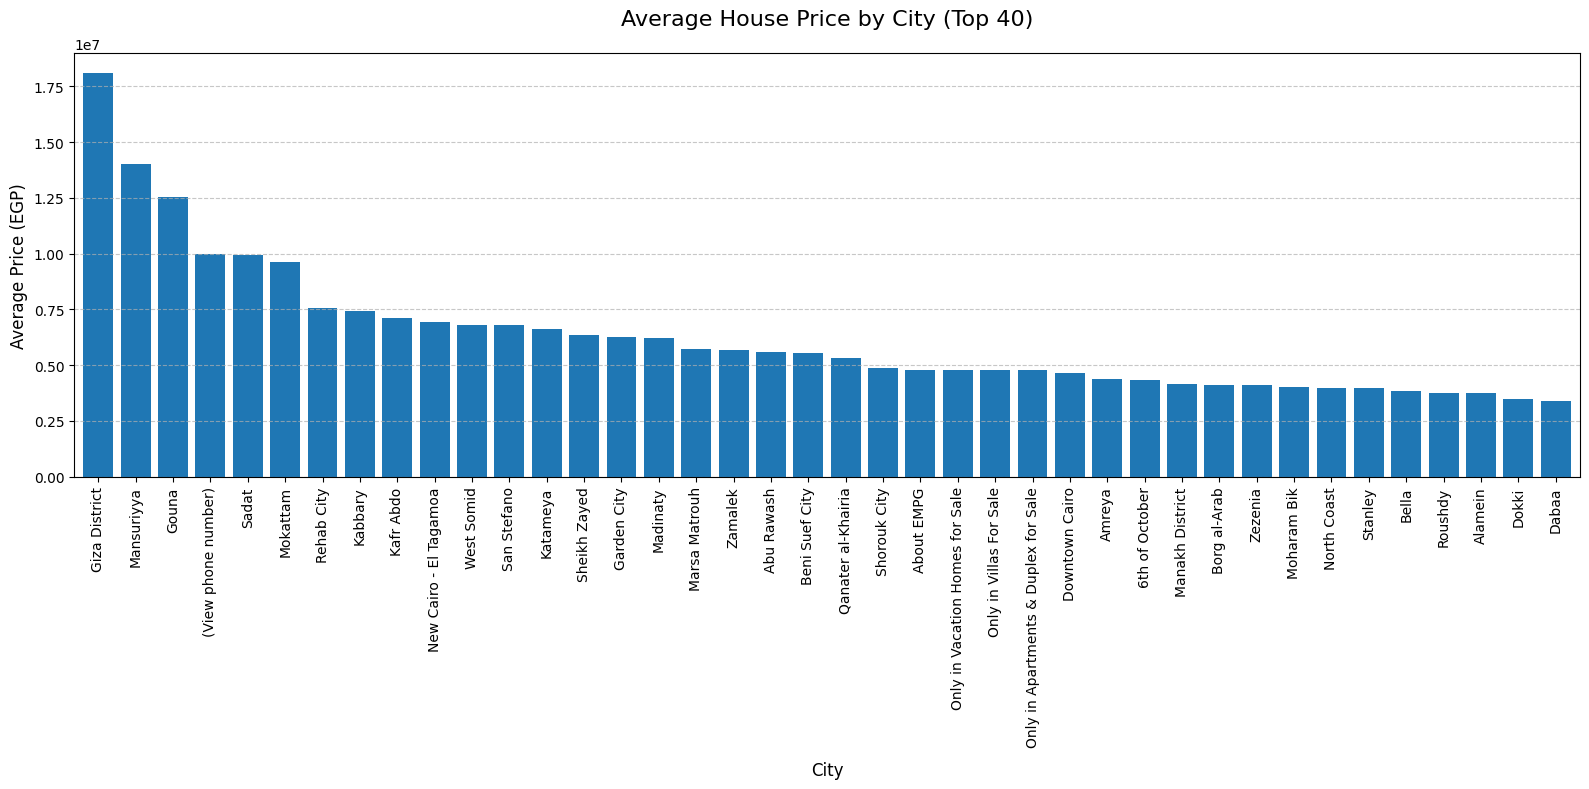

In [116]:
top_15_cities = avg_price_by_city.head(40)  # Reduced to top 40 for clarity

plt.figure(figsize=(16, 8))  

# Create bar plot
ax = top_15_cities.plot(kind='bar', width=0.8)

# Customize the plot
plt.title('Average House Price by City (Top 40)', fontsize=16, pad=20)
plt.xlabel('City', fontsize=12, labelpad=10)  # Added labelpad for spacing
plt.ylabel('Average Price (EGP)', fontsize=12)

# Format x-axis labels vertically
plt.xticks(rotation=90, ha='center', fontsize=10)  # Changed to vertical alignment

# Adjust layout
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.subplots_adjust(bottom=0.2)  # Added space for vertical labels
plt.tight_layout()

plt.show()

10. Save processed dataset:

In [117]:
df.to_csv('Egypt_Houses_Price_Cleaned.csv', index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
